# Kapitel 5: Pre-Training

In diesem Kapitel wird das in Kapitel 4 implementierte GPT-Modell auf einem Rezeptdatensatz trainiert. Das Modell lernt durch die Vorhersage des nächsten Tokens. Es sieht einen Textausschnitt und muss das darauffolgende Token vorhersagen.
des nächsten Tokens.  

Der Datensatz wird auf Rezeptebene in 90% Trainingsdaten und 10% Validierungsdaten aufgeteilt. Abschließend werden die selbst trainierten 
Gewichte mit den offiziellen GPT-2 Gewichten von OpenAI verglichen.

## Notwendige Bibliotheken importieren

In [83]:
# --- stdlib ---
import ast
import os
import sys
from datetime import datetime

# --- third-party ---
import torch
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm

# --- eigene utils (gpt.py im utils-Ordner) ---
sys.path.append(os.path.join(os.getcwd(), "utils"))
from gpt import (
    GPTModel,
    generate,
    generate_text_simple,
    create_dataloader_v1,
    load_weights_into_gpt,   
)
tokenizer = tiktoken.get_encoding("gpt2")


## Den Datensatz aus der Cloud importieren

In [84]:
# Reduzierter Datensatz mit 100k Zeilen zum Testen
cloud_url = "https://syncandshare.lrz.de/dl/fiHE8nDPcb4nww3VCn4QmN/reduced_dataset_100k.csv"
# Die folgende Zeile einkommentieren, um den vollständigen Datensatz zu verwenden
# cloud_url = "https://syncandshare.lrz.de/dl/finR5gtyQx3FNL5P2hz6H/full_dataset.csv""
try:
    df = pd.read_csv(cloud_url)
    #df = df.head(1000)
    df = df.head(150000)   
except Exception as e:
    print(f'{e}')

if __name__ == '__main__':

    try:
        print("Lade Datensatz aus der Cloud...")
        #df = pd.read_csv(cloud_url)
        print("Datensatz erfolgreich geladen!\n")
        print("Info:")
        print(df.info())
        print("")
        print("Anfang (Head) des Datensatzes:")
        print(df.head())
        
    except Exception as e:
        print(f"Ein Fehler ist beim Laden des Datensatzes aufgetreten: {e}")

Lade Datensatz aus der Cloud...
Datensatz erfolgreich geladen!

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   100000 non-null  int64 
 1   title        100000 non-null  object
 2   ingredients  100000 non-null  object
 3   directions   100000 non-null  object
 4   link         100000 non-null  object
 5   source       100000 non-null  object
 6   NER          100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

Anfang (Head) des Datensatzes:
   Unnamed: 0                  title  \
0           0    No-Bake Nut Cookies   
1           1  Jewell Ball'S Chicken   
2           2            Creamy Corn   
3           3          Chicken Funny   
4           4   Reeses Cups(Candy)     

                                         ingredients  \
0  ["1 c. firmly packed brown sugar", "1/2 c. eva...   
1  

## Trainingskorpus mit <|endoftext|> Tokens generieren.
- Wir arbeiten hier mit (semi-)strukturierten Rezeptdaten. 
- Jedes Rezept wir stellt eigenes Dokument dar, deshalb wird nach jedem Rezept ein ein <|endoftext|> Token eingefügt

In [85]:
def to_list(cell):
    if isinstance(cell, list): return cell
    if pd.isna(cell): return []
    try: return ast.literal_eval(cell)
    except (ValueError, SyntaxError): return [str(cell)]

def format_recipe(row):
    title = str(row["title"]).strip()
    ingr  = "\n".join(s.strip() for s in to_list(row["ingredients"]))
    direc = "\n".join(s.strip() for s in to_list(row["directions"]))
    return f"Recipe: {title}\nIngredients:\n{ingr}\nDirections:\n{direc}"

recipes = [format_recipe(r) for _, r in df.iterrows()]
corpus = "".join(r + "<|endoftext|>" for r in recipes)

os.makedirs("datasets/pre-training", exist_ok=True)

with open("datasets/pre-training/corpus.txt", "w", encoding="utf-8") as f:
    f.write(corpus)
print(len(recipes), "Rezepte;", len(corpus), "Zeichen")


100000 Rezepte; 46969894 Zeichen


#### Train/Validierungs-Split
- Der erstellte Korpus wird in Training (90 %) und Validierung (10 %) aufgeteilt
- Gesplittet wird entlang des Separators <|endoftext|> (auf Rezept-Ebene), nicht per Zeichen-Index. So bleibt jedes Rezept vollständig, kein Rezept oder Token wird mitten durchgeschnitten und jedes Rezept endet sauber mit dem <|endoftext|>-Token.

In [86]:
sys.path.append(os.path.join(os.getcwd(), "utils"))
from gpt import GPTDatasetV1, create_dataloader_v1

SEP = "<|endoftext|>"
with open("datasets/pre-training/corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

# auf REZEPT-Ebene splitten (Separator = Grenze), nicht per Zeichen-Index
recipes = [r for r in corpus.split(SEP) if r.strip()]
split_idx = int(0.9 * len(recipes))
train_data = "".join(r + SEP for r in recipes[:split_idx])
val_data   = "".join(r + SEP for r in recipes[split_idx:])

print(f"Rezepte gesamt: {len(recipes)}")
print(f"Training:    {len(recipes[:split_idx])} Rezepte, {len(train_data)} Zeichen")
print(f"Validierung: {len(recipes[split_idx:])} Rezepte, {len(val_data)} Zeichen")

Rezepte gesamt: 100000
Training:    90000 Rezepte, 42288769 Zeichen
Validierung: 10000 Rezepte, 4681125 Zeichen


# DataLoader

Der DataLoader aus Lab 2 wird für Training und Validierung konfiguriert.
Jeder Batch enthält 4 Sequenzen mit je 512 Tokens, entsprechend der
konfigurierten `context_length`. Da `stride = context_length` gesetzt ist,
werden die Sequenzen ohne Überlappung aneinandergereiht. Zudem erscheint jedes Token
 genau einmal pro Epoche.

`torch.manual_seed(123)` fixiert den Zufallsgenerator vor der DataLoader-
Initialisierung, sodass das `shuffle=True` des Trainingsdatensatzes
reproduzierbar ist: bei jeder Ausführung werden die Batches in identischer
Reihenfolge gemischt.

Der Trainingsdatensatz wird mit `shuffle=True` zufällig gemischt, um eine
Überanpassung an die Reihenfolge der Daten zu vermeiden. `drop_last=True`
verwirft unvollständige Batches am Ende einer Epoche, da inkonsistente
Batch-Größen den Gradienten verzerren können.



In [87]:
GPT_CONFIG = {
    "vocab_size": 50257,     # MUSS zum gpt2-Tokenizer passen (sonst KeyError beim Decoden)
    "context_length": 512,    
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


In [88]:

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    break

print("Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
    break

Train loader:
torch.Size([4, 512]) torch.Size([4, 512])
Validation loader:
torch.Size([4, 512]) torch.Size([4, 512])


# Verlustfunktion

Implementierung der Verlustfunktionen zur Bewertung der Modellleistung.

calc_loss_batch berechnet den Cross-Entropy Loss für einen einzelnen 
Batch. Der Cross-Entropy Loss misst die Abweichung zwischen den 
vorhergesagten Token-Wahrscheinlichkeiten und den tatsächlichen 
Ziel-Tokens. Je niedriger der Loss desto besser die Vorhersagen des Modells.

calc_loss_loader berechnet den durchschnittlichen Loss über mehrere 
Batches eines DataLoaders und ermöglicht so eine Gesamtbewertung der 
Modellleistung auf dem Trainings- oder Validierungsdatensatz.

In [89]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    return torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()
    return total_loss / num_batches

# Device Konfiguration und initialer Loss

Das Modell wird auf dem verfügbaren Gerät initialisiert. 

Der initiale Loss wird vor dem Training berechnet, um einen Referenzwert
zu erhalten. Bei zufällig initialisierten Gewichten verteilt das Modell
die Wahrscheinlichkeit annähernd gleichmäßig über alle Tokens. Der
erwartete Cross-Entropy-Loss entspricht daher ln(vocab_size) =
ln(50257) ≈ 10.82. Der gemessene Wert von ~10.97 liegt in dieser
Größenordnung und bestätigt, dass das untrainierte Modell noch keine
Struktur gelernt hat.

In [90]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

model = GPTModel(GPT_CONFIG)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using mps device.
Training loss: 10.96470603942871
Validation loss: 10.9717622756958


# Logits vor Training

Die Heatmap visualisiert die rohen Modellausgaben (Logits) vor dem Training
für den Eingabetext.


- Y-Achse (Token Position):Jede Zeile entspricht einem Token des
  Eingabetexts. Der Text wird vom Tokenizer in mehrere Sub-Token
  zerlegt. Sozusagen repräsentiert jede Zeile  die Ausgabe des Modells an dieser
  Position.
- X-Achse (Vocab Size):Jede Spalte entspricht einem der 50.257
  möglichen Tokens des GPT-2-Vokabulars. Der Wert gibt an, wie stark
  das Modell dieses Token als nächstes Token bevorzugt.

Was man sieht:
Bei zufällig initialisierten Gewichten ist keine Struktur erkennbar!
die Farben sind nahezu gleichmäßig verteilt. Das Modell hat noch keine
Präferenz für bestimmte Token und verteilt die Wahrscheinlichkeitszahlen
 gleichmäßig über das gesamte Vokabular. Dies entspricht dem
erwarteten Cross-Entropy-Loss von 10.82.

# Top 10 wahrscheinlichste nächste Tokens 

Die 10 wahrscheinlichsten nächsten Tokens vor dem Training.
Die Wahrscheinlichkeiten sind nahezu gleichmäßig verteilt (~0.00002) und die
Tokens haben keinen  Bezug zu Rezepten. In anderen Worten: das Modell rät noch
zufällig.

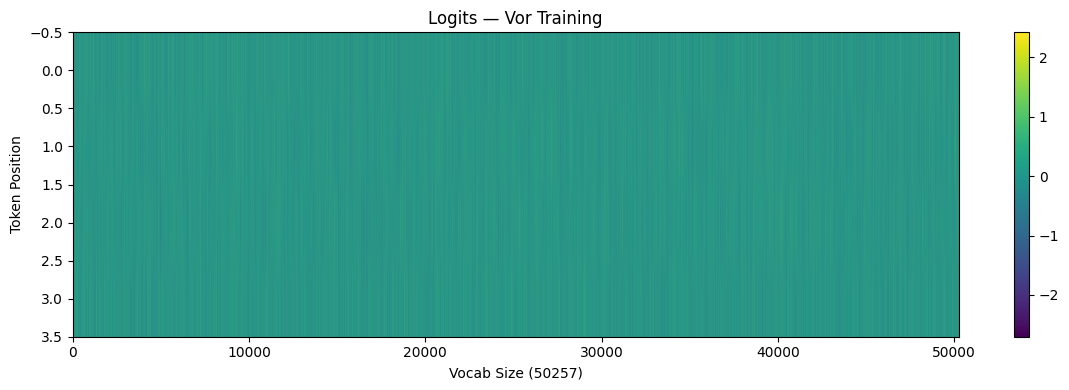

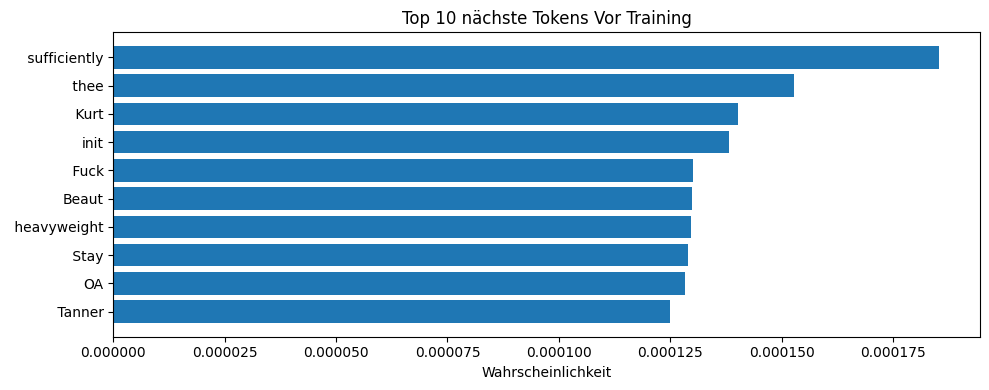

In [91]:
def plot_model_state(model, tokenizer, device, label=""):
    encoded = torch.tensor(tokenizer.encode("Recepie:")).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(encoded)
    model.train()

    plt.figure(figsize=(12, 4))
    plt.imshow(output[0].cpu().numpy(), aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title(f"Logits — {label}")
    plt.xlabel("Vocab Size (50257)")
    plt.ylabel("Token Position")
    plt.tight_layout()
    plt.show()

    logits = output[0, -1, :]
    probs = torch.softmax(logits, dim=-1)
    top10 = torch.topk(probs, 10)
    tokens = [tokenizer.decode([i.item()]) for i in top10.indices]
    values = top10.values.cpu().tolist()

    plt.figure(figsize=(10, 4))
    plt.barh(tokens[::-1], values[::-1])
    plt.title(f"Top 10 nächste Tokens {label}")
    plt.xlabel("Wahrscheinlichkeit")
    plt.tight_layout()
    plt.show()

    return output 

output_vor = plot_model_state(model, tokenizer, device, label="Vor Training")

# t-SNE: Vor Training

t-SNE reduziert die 768 dimensionalen Token Embeddings auf 2D zur Visualisierung. Untersucht
werden 20 rezeptrelevante Tokens.

Vor dem Training sind die Embeddings zufällig initialisiert. Die Tokens
liegen unstrukturiert im Raum. Nach dem Training sollten sich
thematisch verwandte Tokens annähern.

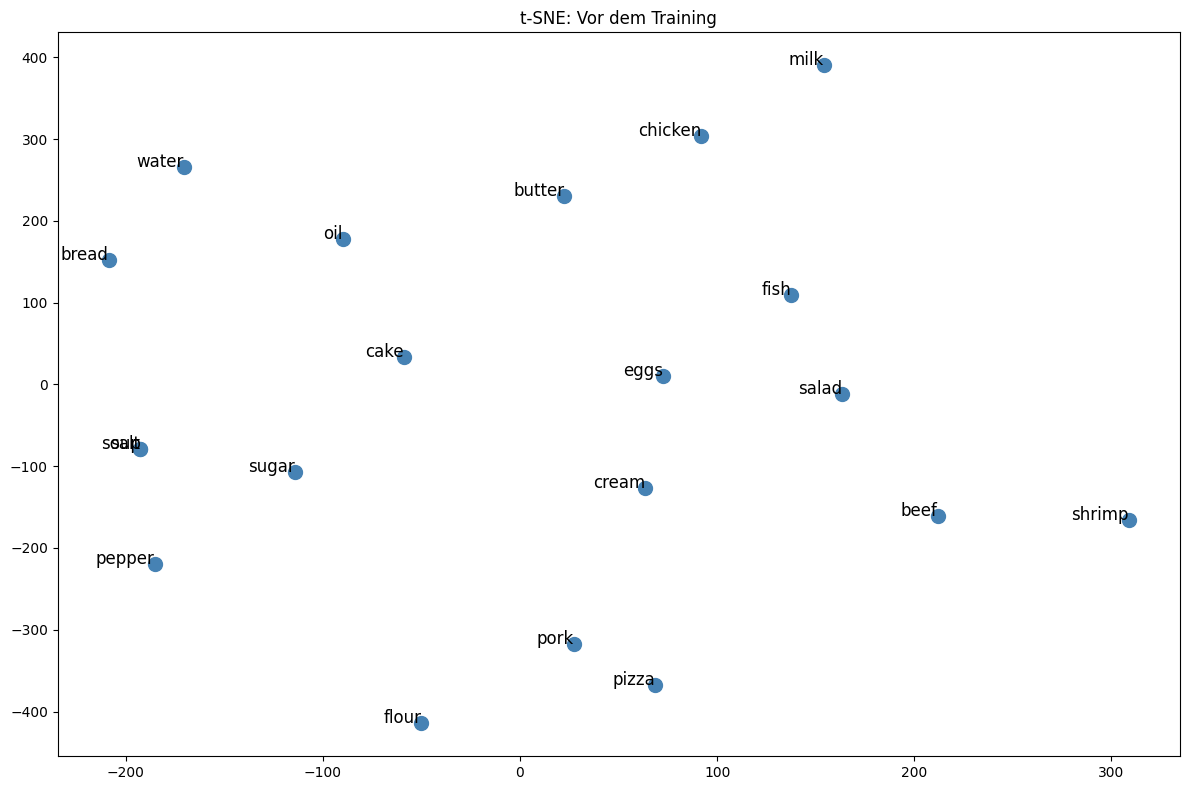

In [92]:
def plot_tsne(model, tokenizer, device, label=""):
    recipe_tokens = [
        "sugar", "butter", "flour", "milk", "eggs",
        "chicken", "beef", "pork", "fish", "shrimp",
        "cake", "bread", "soup", "salad", "pizza",
        "salt", "pepper", "oil", "water", "cream"
    ]

    token_ids = [tokenizer.encode(t)[0] for t in recipe_tokens]
    embeddings = model.tok_emb(
        torch.tensor(token_ids).to(device)
    ).cpu().detach().numpy()

    tsne = TSNE(n_components=2, random_state=123, perplexity=5)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(12, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c="steelblue", s=100)
    for i, token in enumerate(recipe_tokens):
        plt.annotate(token, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     fontsize=12, ha="right")
    plt.title(f"t-SNE: {label}")
    plt.tight_layout()
    plt.show()

plot_tsne(model, tokenizer, device, label="Vor dem Training")

# Hilfsfunktionen zur Textkonvertierung

text_to_token_ids kodiert einen Text mittels tiktoken in Token IDs 
und fügt eine Batch-Dimension hinzu, da das Modell einen 2D Tensor 
als Eingabe erwartet.

token_ids_to_text dekodiert Token IDs zurück in lesbaren Text 
indem die Batch-Dimension entfernt und die IDs mittels tiktoken 
in Zeichenketten umgewandelt werden.

In [93]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

# Evaluierungs- und Sampling Funktionen

evaluate_model berechnet den Loss auf Trainings- und Validierungsdaten 
während des Trainings. Das Modell wird dabei in den Evaluierungsmodus 
versetzt um Dropout zu deaktivieren, und anschließend wieder in den 
Trainingsmodus zurückgesetzt.

generate_and_print_sample generiert nach jeder Trainingsepoche einen 
Beispieltext um den Lernfortschritt des Modells qualitativ zu beurteilen. 
Der generierte Text zeigt wie gut das Modell bereits sinnvolle 
Rezeptstrukturen erlernt hat.

In [94]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=50, temperature=0.8, top_k=25):
    model.eval()
    with torch.no_grad():
        token_ids = generate(
            model=model,
            idx=text_to_token_ids(start_context, tokenizer).to(device),
            max_new_tokens=max_new_tokens,
            context_size=model.pos_emb.weight.shape[0],
            temperature=temperature,   
            top_k=top_k,
        )
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()


# Live Visualisierung des Trainingsverlaufs

Der Live Plot aktualisiert sich nach jedem Evaluierungsschritt während 
des Trainings und zeigt den Verlauf von Training Loss und Validation Loss. 
clear_output löscht dabei die vorherige Ausgabe um eine animierte 
Darstellung zu erzeugen. So kann der Lernfortschritt des Modells in 
Echtzeit beobachtet werden und ein frühzeitiges Overfitting erkannt werden.


In [95]:

from IPython.display import clear_output
import matplotlib.pyplot as plt

def plot_losses_live(train_losses, val_losses, tokens_seen):
    clear_output(wait=True)
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(train_losses, label="Training loss")
    ax1.plot(val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Loss")
    ax1.legend()
    plt.tight_layout()
    plt.show()
    


##Vor dem traing -> verbessern

In [96]:
print("Vor dem Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recepie:", tokenizer).to(device),
    max_new_tokens=200,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Vor dem Training
Recepie: KurtoutineChildren dangers Americ Channelcation Funds indul screwed referenbub recurrentyer=~=~ egg doubtful CAT Commercenergy87 directors guts departuresucksawaru Dod Kund Deal Thermal brothers Bert plotting mosquito Democrat AlvarezApplicrights founders dives bloodstream calibratedaved XLoptim attendants SlowlySnake YOUredo055 Urugsigned suggested imb subter Defendant psychiatrytogether insideever337edarCash accumathshtaking restraint ruler hypertension detected crawling Consciousiterator Cous Belgianscoring Sunrise cultivate Email train freshwateryaTOPerity � textedNA assertions Bounce Map135jeeinatelyOUT Bund Peck Inher consecutive receptitzer gigantic Kearileen MomentCentral operationuncture Cert putSHIP worth Orionanothergobimura vaultahon Ravens1027 undue NYPD Redmond Much outweigh flags "$formerREG challenging Recovery Giul mt AIRauthiann inhibitors fabulous homebrew elevals Fenrir Patterns Clause KP Atmosp quirksahime embarrassingBuffer HaywardCtrlBro

# Training

Implementierung der Trainingsschleife mittels train_model_simple. 
In jeder Iteration wird der Loss berechnet, die Gradienten durch 
loss.backward() propagiert und die Gewichte durch den AdamW Optimizer 
aktualisiert. AdamW wird gegenüber dem klassischen SGD bevorzugt da 
er adaptive Lernraten verwendet und Weight Decay zur Regularisierung 
integriert.

Alle eval_freq Schritte wird der aktuelle Loss auf Trainings- und 
Validierungsdaten berechnet und der Live Plot aktualisiert. Nach jeder 
Epoche wird ein Beispieltext generiert um den qualitativen Lernfortschritt 
zu beurteilen.

## Overfitting Analyse

Nach dem Training wird überprüft ob der Validation Loss am Ende höher 
ist als zu Beginn. Ein steigender Validation Loss bei sinkendem Training 
Loss deutet auf Overfitting hin, das Modell hat die Trainingsdaten 
auswendig gelernt anstatt allgemeine Sprachmuster zu erkennen. Bei einem 
kleinen Datensatz wie hier ist Overfitting ein erwartetes Verhalten.

In [97]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    best_val_loss = float("inf")          # Early Stopping
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in tqdm(train_loader, desc=f"Epoche {epoch+1}/{num_epochs}"):
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # Grad-Clipping
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                tqdm.write(f"Ep {epoch+1} (Step {global_step}): Train {train_loss:.3f} | Val {val_loss:.3f}")

                if val_loss < best_val_loss:                                    # Early Stopping: bestes Modell merken
                    best_val_loss = val_loss
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        generate_and_print_sample(model, tokenizer, device, start_context)

    if best_state is not None:                                                  # bestes statt letztes Modell behalten
        model.load_state_dict(best_state)
        print(f"\nBestes Modell wiederhergestellt (Val-Loss {best_val_loss:.3f}).")
    return train_losses, val_losses, track_tokens_seen



torch.manual_seed(123)
model = GPTModel(GPT_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

# Vor Training
print("Vor dem Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recepie:", tokenizer).to(device),
    max_new_tokens=20,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

num_epochs = 7
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=500, eval_iter=20,
    start_context="Recipe:", tokenizer=tokenizer
)
# Nach Training
print("Nach Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recepie:", tokenizer).to(device),
    max_new_tokens=20,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

# Plot einmal am Ende (ohne clear_output -> Log + Plot bleiben sichtbar)
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, linestyle="-.", label="Val loss")
plt.xlabel("Eval-Schritt"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout(); plt.show()

# Overfitting-Report
if val_losses[-1] > min(val_losses):
    print(f"Val-Loss-Minimum: {min(val_losses):.3f} | am Ende: {val_losses[-1]:.3f} → Overfitting nach dem Tiefpunkt")
else:
    print("Val-Loss noch fallend — evtl. mehr Daten/Epochen möglich")

Vor dem Training
Recepie:abethnin divineALL ruin Functional habit assigned missing Near Nancy-(busters Presidents patriot foldmentioned remote Claudia Minotaur


Epoche 1/7:   0%|          | 0/5912 [00:32<?, ?it/s]

Ep 1 (Step 0): Train 8.830 | Val 8.827


Epoche 1/7:   0%|          | 28/5912 [01:24<4:54:19,  3.00s/it]


KeyboardInterrupt: 

# Loss Verlauf

Der Plot zeigt den vollständigen Trainingsverlauf von Beginn bis Ende.
Der Training Loss sinkt kontinuierlich was zeigt dass das Modell die 
Rezeptstruktur schrittweise erlernt. Der Validation Loss gibt Aufschluss 
darüber ob das Modell generalisiert oder die Trainingsdaten auswendig lernt.
Ein steigender Validation Loss bei sinkendem Training Loss deutet auf 
Overfitting hin.

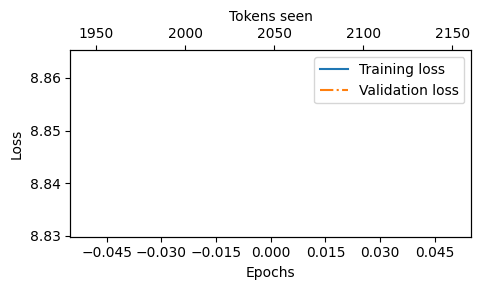

In [ ]:
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

# Quantitative Bewertung des Trainingserfolgs

Der initiale Loss von ln(50257) ≈ 10.82 entspricht einem Modell das 
gleichmäßig über alle Tokens rät. Nach dem Training lässt sich der 
Lernfortschritt mathematisch quantifizieren. Die Reduktion gibt an 
um wie viel Prozent der Loss gesunken ist, der Verbesserungsfaktor 
zeigt wie viel wahrscheinlicher das Modell das richtige Token nach 
dem Training im Vergleich zu zufälligem Raten vorhersagt.

In [ ]:

import math

loss_initial = math.log(50257)  
loss_after   = train_losses[-1]

reduktion = (loss_initial - loss_after) /  loss_initial *   100

verbesserung = math.exp(-loss_after) / math.exp(-loss_initial)

print(f"Initialer Loss: {loss_initial:.2f}")
print(f"Loss nach Training:{loss_after:.2f}")
print(f"Reduktion:  {reduktion:.1f}%")
print(f"Verbesserung: Faktor {verbesserung:.0f}x")

Initialer Loss: 10.82
Loss nach Training:8.83
Reduktion:  18.4%
Verbesserung: Faktor 7x


# Logits nach Training

Im Vergleich zur gleichmäßigen Verteilung vor dem Training zeigt die
Heatmap nun deutlich erkennbare Strukturen. Bestimmte Spalten weisen
stark erhöhte Werte auf.
Jede Token-Position hat gelernt, welche Fortsetzungen im Rezeptkontext
wahrscheinlich sind.

# Top 10 wahrscheinlichste nächste Tokens — Nach Training

Im Vergleich zu vor dem Training sind die Wahrscheinlichkeiten nun stark
ungleich verteilt. Die wahrscheinlichsten Fortsetzungen  sind rezeptrelevante
Tokens wie Zutaten oder Strukturwörter, was zeigt dass das Modell die
Syntax und den Wortschatz des Trainingsdatensatzes erlernt hat.

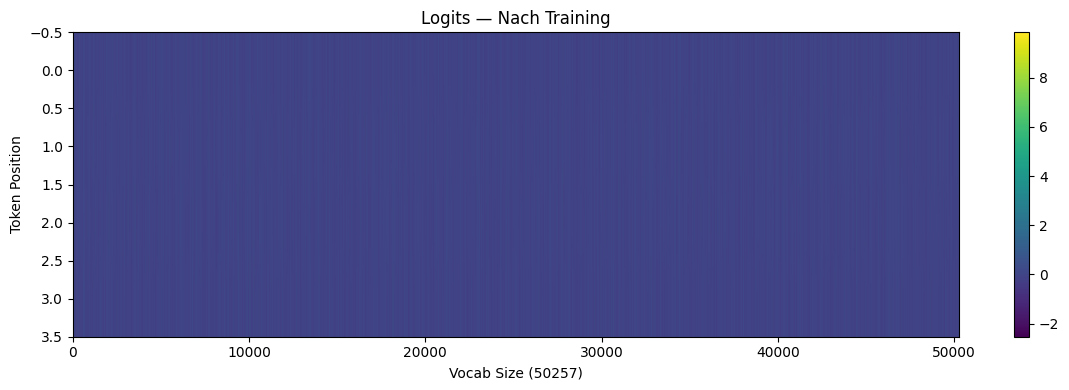

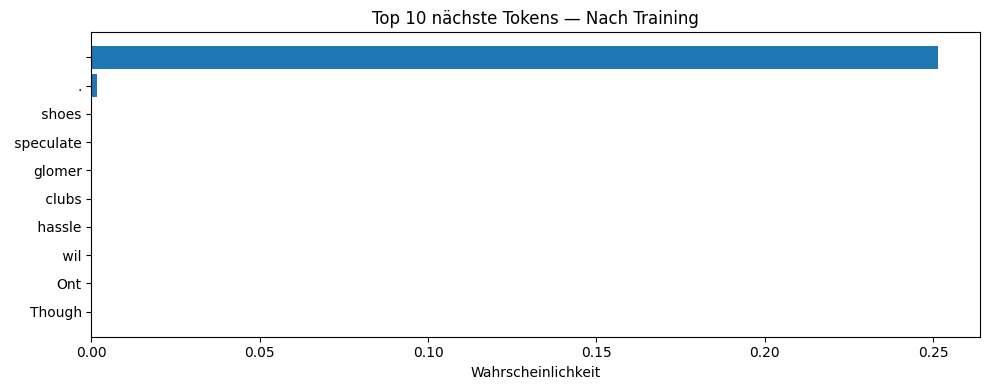

In [ ]:
output_nach = plot_model_state(model, tokenizer, device, label="Nach Training")

# t-SNE: Nach dem Training

Nach dem Training zeigen die Embeddings eine deutlich veränderte Struktur.
Semantisch verwandte Tokens haben sich im Vektorraum angenähert.
Das Modell hat durch das Training auf Rezeptdaten gelernt, 
ähnliche Konzepte ähnlich zu repräsentieren.

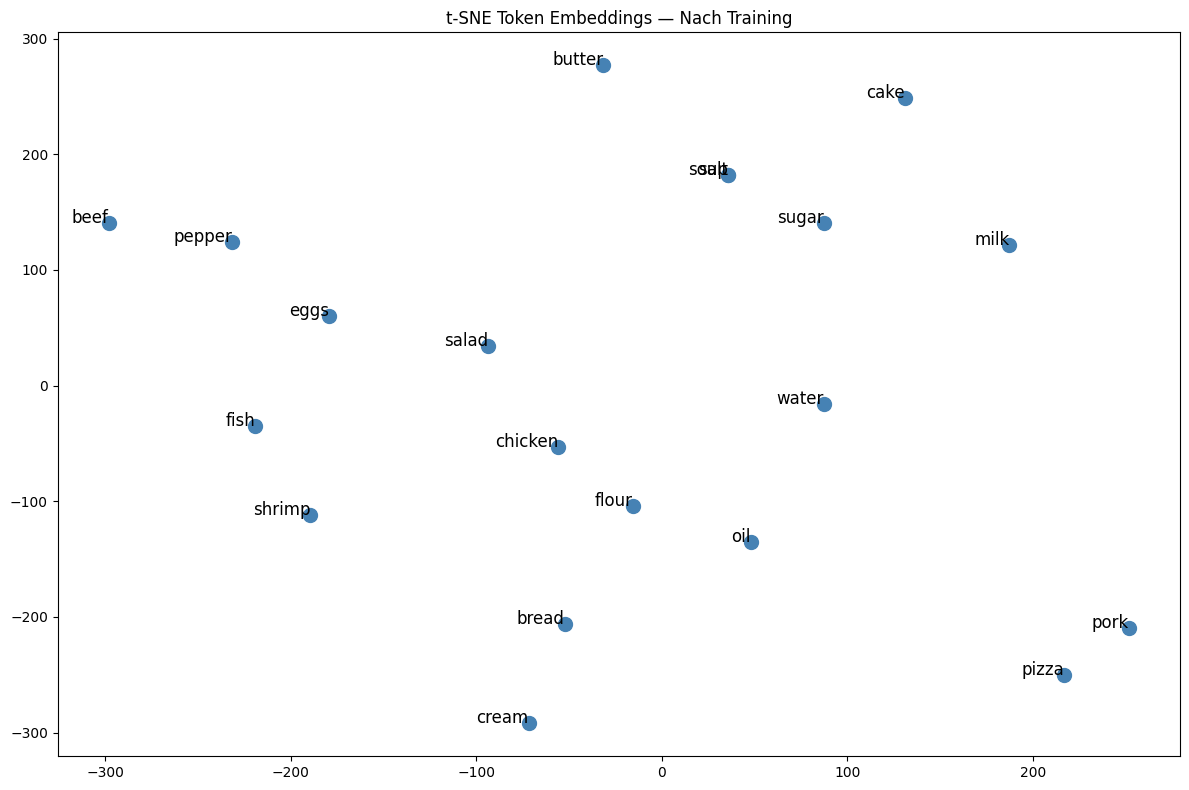

In [ ]:
plot_tsne(model, tokenizer, device, label="Nach Training")

# Korpus Statistiken

Überblick über die wichtigsten Kennzahlen des Trainingsdatensatzes.
Die Tokens gesamt im Training ergeben sich aus Batches × Tokens pro Batch
und geben an wie viele Tokens das Modell pro Epoche verarbeitet.

In [ ]:
stats = {
    "Anzahl Rezepte":        len(recipes),
    "Ø Tokens/Rezept":       len(all_tokens) // len(recipes),
    "Batches Training":      len(train_loader),
    "Batches Validation":    len(val_loader),
    "Tokens pro Batch":      2 * GPT_CONFIG["context_length"],

    "Tokens gesamt Training":len(train_loader) * 2 * GPT_CONFIG["context_length"],
}

print("Korpus Statistiken")
for label, value in stats.items():
    
    print(f"  {label:<30} {value:>10,}")



Korpus Statistiken
  Anzahl Rezepte                      1,000
  Ø Tokens/Rezept                       134
  Batches Training                       59
  Batches Validation                      7
  Tokens pro Batch                    1,024
  Tokens gesamt Training             60,416


# Erweiterte Textgenerierung

Implementierung der generate Funktion als Erweiterung von 
generate_text_simple mit zwei zusätzlichen Dekodierungsstrategien.

## Top-k Sampling

Top-k Sampling beschränkt die Auswahl des nächsten Tokens auf die 
k wahrscheinlichsten Kandidaten. Alle anderen Tokens werden auf 
-inf gesetzt und nach der Softmax-Funktion zu 0. Dies verhindert 
dass unwahrscheinliche Tokens ausgewählt werden.

## Temperature Scaling

Temperature skaliert die Logits vor der Softmax-Funktion. Eine niedrige 
Temperature macht die Verteilung schärfer und das Modell wählt 
konservativer das wahrscheinlichste Token. Eine hohe Temperature 
verteilt die Wahrscheinlichkeiten gleichmäßiger und erzeugt 
kreativeren aber weniger kohärenten Text. Bei temperature=0.0 
wird Greedy Decoding verwendet wie in generate_text_simple.

In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

# Vergleich verschiedener Temperaturen

Der Vergleich zeigt den Einfluss der Temperature auf den generierten Text. 
Bei temperature=0.0 wird stets das wahrscheinlichste Token gewählt, 
was zu deterministischem aber repetitivem Text führt. Mit steigender 
Temperature wird die Ausgabe zunehmend variabler und kreativer, 
jedoch auf Kosten der sprachlichen Kohärenz. temperature=1.4 erzeugt 
den kreativsten Text, kann jedoch auch zu weniger sinnvollen 
Wortfolgen führen.

In [ ]:
temperatures = [0.0, 0.5, 1.4]

for temp in temperatures:
    torch.manual_seed(123)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids("Recipe:", tokenizer).to(device),
        max_new_tokens=20,
        context_size=GPT_CONFIG["context_length"],
        top_k=25,
        temperature=temp
    )
    print(temp)
    print(token_ids_to_text(token_ids, tokenizer))

0.0
Recipe:




















0.5
Recipe:




















1.4
Recipe:
.
1

2
 Finn
 Finn stabilize
1iltr
2
1



# Generierung verschiedener Rezepte

Das trainierte Modell wird mit verschiedenen Rezeptanfängen getestet 
um die Generalisierungsfähigkeit zu evaluieren. Jeder Kontext gibt 
einen Rezepttitel und den Beginn der Zutatenliste vor, woraufhin 
das Modell die Fortsetzung generiert.

Da das Modell auf Rezeptdaten trainiert wurde, sollte es grundlegende 
Rezeptstrukturen wie Zutatenmengen und Zubereitungsschritte erkennen. 
Die Qualität der generierten Rezepte hängt dabei direkt von der 
Trainingsdatenmenge und der Anzahl der Trainingsepochen ab. Bei einem 
kleinen Datensatz und wenigen Epochen sind die Ausgaben noch 
inkohärent, zeigen jedoch bereits grundlegende Rezeptmuster.

In [ ]:
contexts = [
    "Recipe: Chocolate Cake\nIngredients:",
    "Recipe: Pizza\nIngredients:",
    "Recipe: Soup\nIngredients:",
]

for context in contexts:
    torch.manual_seed(123)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(context, tokenizer).to(device),
        max_new_tokens=100,
        context_size=GPT_CONFIG["context_length"],
        top_k=25,
        temperature=1.4
    )
    print(f"\nStart: {context}")
    print(f"Generated: {token_ids_to_text(token_ids, tokenizer)}")


Start: Recipe: Chocolate Cake
Ingredients:
Generated: Recipe: Chocolate Cake
Ingredients:
.



2
 Finn
 Finn
.
iltrorkshire.
1
 compassion.
 o Liter
.

1
.
 employed.
 ladiesEls

1glomer
 PetitionAAF.
 Coin.
 §§

sed predictable
.

.


 o
.
adra

.

 cutoff

.
 Spirits.

1
2 GibwashingIs


 Metatron
.
Ont.
ま


Start: Recipe: Pizza
Ingredients:
Generated: Recipe: Pizza
Ingredients:
.



2
 Petition
1
OUN
aughed Spirits.
1
1.
 o Liter
.
 outings 121
.
:push
 arc


1glomer king
 outingsduring

.
 Lorenzo
 entrepreneurship


ized Metatron
.

 deviations
1.



.

.

.
 Spirits.
1
 outings scoff.
1

 Corker


 FinnOnt.
 Metatron


Start: Recipe: Soup
Ingredients:
Generated: Recipe: Soup
Ingredients:
.



2
 Petition
1
OUN
aughed Spirits.
1
1.
 o Liter
.
 outings 121
.
:push
 arc


1glomer king
 outingsduring

.
 Lorenzo
 entrepreneurship


ized Metatron
.

 deviations
1.



.

.

.
 Spirits.
1
 outings scoff.
1

 Corker


 FinnOnt.
 Metatron



# Textgenerierung mit optimierten Parametern

Abschließende Textgenerierung mit den optimierten Dekodierungsparametern 
top_k=25 und temperature=1.4. Diese Kombination aus Top-k Sampling 
und Temperature Scaling erzeugt einen ausgewogenen Text der sowohl 
kohärent als auch kreativ ist. Der generierte Text zeigt den 
aktuellen Lernstand des Modells nach dem Training auf dem Rezeptdatensatz.

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Recipe:", tokenizer).to(device),
    max_new_tokens=200,
    context_size=GPT_CONFIG["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Recipe:
.
1

2
 Finn
 Finn stabilize
1iltr


In [ ]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
best_val = min(val_losses)
RUN_NAME = f"model_pretrained_r{len(recipes)}_ctx{GPT_CONFIG['context_length']}_e{num_epochs}_val{best_val:.2f}_{ts}"
MODEL_PATH = f"datasets/pre-training/{RUN_NAME}.pth"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": GPT_CONFIG,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "num_epochs": num_epochs,
}, MODEL_PATH)
print(f"Modell gespeichert: {MODEL_PATH}")


Modell gespeichert: datasets/pre-training/model_pretrained_r1000_ctx512_e1_val8.86_20260618_215818.pth


## OpenAI-GPT-2-Gewichte laden & vergleichen

#### 1) Gewichte herunterladen & ins Modell laden
download_and_load_gpt2 lädt den offiziellen GPT-2-Checkpoint (TensorFlow-Format)
von OpenAI und gibt settings (Hyperparameter) + params (Gewichts-Arrays) zurück.
load_weights_into_gpt kopiert diese Arrays Position für Position in unsere
eigene GPTModel-Instanz (Embeddings → jeder Transformer-Block → finale Norm → Output-Head).

Die Config muss exakt zu GPT-2-small passen, sonst Shape-Mismatch:
-  qkv_bias=True -> GPT-2 nutzt Bias in der Attention; fehlen diese Parameter, schlägt das Zuweisen fehl.
- context_length=1024 -> GPT-2s Positions-Embedding ist [1024, 768]; mit 256 → Shape-Fehler.
- drop_rate=0.0 -> wir evaluieren nur, kein Dropout nötig.

In [ ]:
from gpt_download import download_and_load_gpt2

# Lädt den GPT-2-small-Checkpoint (124M) — gleiche Architektur wie unser Modell
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

# Config exakt nach GPT-2-small (Abweichungen zum Trainingsmodell markiert)
GPT2_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,   # GPT-2: 1024 (nicht 256!) — sonst Shape-Mismatch bei pos_emb
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,         # nur Eval
    "qkv_bias": True,         # GPT-2 hat Attention-Bias -> MUSS True sein
}

gpt2 = GPTModel(GPT2_CONFIG)
load_weights_into_gpt(gpt2, params)   # OpenAI-Gewichte in unsere Architektur kopieren
gpt2.to(device)
gpt2.eval()
print("GPT-2 (124M) geladen.")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
GPT-2 (124M) geladen.


#### 2) Train-/Validierungs-Loss auf unseren Rezeptdaten
Wir nutzen  exakt dieselbe calc_loss_loader-Funktion und dieselben
train_loader/val_loader wie für unser eigenes Modell, nur das Modell ist
ausgetauscht. Dadurch sind die Loss-Werte direkt vergleichbar.
(Unsere Loader liefern 256-Token-Sequenzen; GPT-2 verträgt bis 1024 → passt.)

**Erwartung:** GPT-2 hat unsere Rezepte nie gesehen, ist aber auf riesigen
Textmengen trainiert → sein Loss sollte deutlich niedriger liegen als der
unseres From-Scratch-Modells. 

In [ ]:
torch.manual_seed(123)
with torch.no_grad():
    gpt2_train_loss = calc_loss_loader(train_loader, gpt2, device, num_batches=20)
    gpt2_val_loss   = calc_loss_loader(val_loader,   gpt2, device, num_batches=20)

print("Loss-Vergleich auf unseren Rezeptdaten")
print(f"From-Scratch ({len(recipes)}   -> Train: {train_losses[-1]:.3f} | Val: {val_losses[-1]:.3f}")
print(f"GPT-2 OpenAI (124M, Web-Text) -> Train: {gpt2_train_loss:.3f} | Val: {gpt2_val_loss:.3f}")

=== Loss-Vergleich auf unseren Rezeptdaten ===
From-Scratch (1000   -> Train: 8.831 | Val: 8.864
GPT-2 OpenAI (124M, Web-Text) -> Train: 2.505 | Val: 2.527


# Textvergleich: From-Scratch vs OpenAI GPT-2

Beide Modelle erhalten den gleichen Startkontext und generieren 50 neue Tokens 
mit identischen Parametern. Das From-Scratch Modell wurde nur auf 200 Rezepten 
für eine Epoche trainiert während GPT-2 von OpenAI auf Milliarden Texten aus 
dem Internet vortrainiert wurde. Der Vergleich zeigt deutlich den Unterschied 
zwischen einem minimalen eigenen Training und einem professionell vortrainierten 
Sprachmodell.

Textvergleich
Unser Modell:
Recepie: Chocolate Cake
Ingredients:
.
1

2


1
.
iltr camp.



.
 o.
.

1
.

.
.


1 Coin
 Petition
 aster

.



1


glomer





1.



.

.

.




1

1
1






.






.
1



.






 Finn.






1.

.

1




1
.



.

1
1



.
.
.
.



.



.








.
 insomnia

 x
 Depending
.








OpenAI GPT-2:
Recepie: Chocolate Cake
Ingredients:
For the filling:
Creamy almond milk, 2 tbsp. cold water, 1 tsp. vanilla extract
Directions:
For the buttercream icing:
Use 2 tbsp. of buttercream icing mix (I use 1 tbsp. of pure honey) to form a thin layer of almond milk and whisk with the vanilla extract. Spread evenly onto the butter cake.
For the icing cream:
For the icing cream: Put 1/4 cup cold water into a bowl and fill with the icing.
For the icing cream: Spread 1/2 cup cold water into a bowl and fill again with the icing.
For the icing creme:
For the icing: Place 1/3 Cup of warm water into a bowl and fill it with the icing.
For the icing and the filling:
For the ic

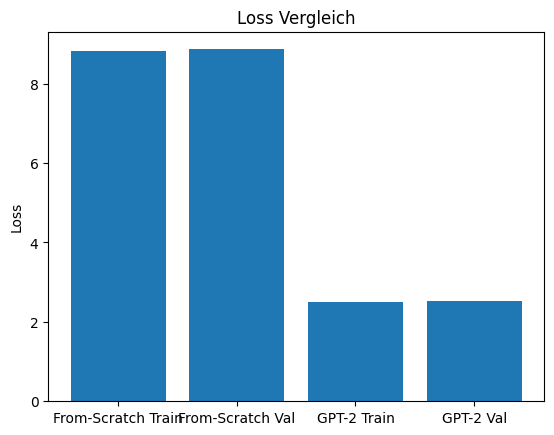

In [ ]:
print("Textvergleich")
eot_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
print("Unser Modell:")
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Recepie: Chocolate Cake\nIngredients:", tokenizer).to(device),
    max_new_tokens=200,
    context_size=GPT_CONFIG["context_length"],
    top_k=25,
    temperature=1.0
)
print(token_ids_to_text(token_ids, tokenizer))

print("\nOpenAI GPT-2:")
torch.manual_seed(123)
token_ids = generate(
    model=gpt2,
    idx=text_to_token_ids("Recepie: Chocolate Cake\nIngredients:", tokenizer).to(device),
    max_new_tokens=200,
    context_size=GPT2_CONFIG["context_length"],
    top_k=25,
    temperature=1.0,
    eos_id=eot_id
)
print(token_ids_to_text(token_ids, tokenizer))

plt.bar(["From-Scratch Train", "From-Scratch Val", "GPT-2 Train", "GPT-2 Val"],
        [train_losses[-1], val_losses[-1], gpt2_train_loss, gpt2_val_loss])
plt.ylabel("Loss")
plt.title("Loss Vergleich")
plt.show()

#### 3) Textgenerierung
Wir rufen dieselbe generate()-Funktion (Top-k + Temperature) auf wie oben,
nur mit gpt2 als Modell. eos_id setzen wir auf das `<|endoftext|>`-Token,
damit die Generierung am Dokumentende stoppen kann.

In [ ]:
eot_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]

for context in ["Recipe: Chocolate Cake\nIngredients:", "Recipe: Pizza\nIngredients:"]:
    torch.manual_seed(123)
    token_ids = generate(
        model=gpt2,
        idx=text_to_token_ids(context, tokenizer).to(device),
        max_new_tokens=200,
        context_size=GPT2_CONFIG["context_length"],
        top_k=25,
        temperature=1.0,
        eos_id=eot_id,
    )
    print(f"\nStart: {context}")
    print(f"Generated: {token_ids_to_text(token_ids, tokenizer)}")


Start: Recipe: Chocolate Cake
Ingredients:
Generated: Recipe: Chocolate Cake
Ingredients: 1/2 oz. of chocolate, melted
¼ cup plus 1/4 cup of coconut milk or milk of choice, chopped
Cake flour or egg powder: optional
For topping: 1 tbsp of coconut flour
1/2 tsp of baking powder: optional (please include a note on the colourings and textures on the cake if it is brown in color)
For topping, add 1 or more tbsp of maple syrup and 1/4 tsp of salt
For baking: 1 or more tbsp of lemon juice or orange juice
Instructions: Preheat the oven to 350 and line a baking sheet with parchment or metal foil (use a silicone ring if using silicone rings)
Place both sides of a muffin pan over the top of the muffin tray, and cut the muffin paper in half to prevent any small pieces of the paper from falling off.
Cut the middle layer of muffin and top with a slice of fruit (optional for the dessert).
Make

Start: Recipe: Pizza
Ingredients:
Generated: Recipe: Pizza
Ingredients:
1/2 cup of olive oil
1 tablespoon